# Loading Data

## Env

In [1]:
from pathlib import Path
import sys
import logging

project_root = str(Path("/home/user/perso/trading/alphalab").resolve())

if project_root not in sys.path:
    sys.path.append(project_root)

# Configuration de l'autocomplétion Jupyter
%config IPCompleter.use_jedi = False
%config IPCompleter.greedy = False

# Activation de l'autoreload
%load_ext autoreload
%autoreload 2

logging.basicConfig(
    level=logging.INFO,
    format='[%(levelname)s] %(message)s',
    stream=sys.stdout,
    force=False,
)

logging.getLogger('enl').setLevel(logging.INFO)

## Fix Panda

In [2]:
import pandas as pd

# Supprime la limite d'affichage des colonnes pour cette session
pd.set_option('display.max_columns', None)

# (Optionnel) Supprime aussi la limite d'affichage des lignes si besoin
pd.set_option('display.max_rows', 10)


## Load Times Bars (30min)

In [3]:
from enl.data_feed import *

start = '2020-01-01'
end = '2021-12-31'

# start = '2026-01-01'
# end = '2026-06-30'

df_30min = load_pair_time_bars('GBPUSD', 'EURUSD', start, end, '30min', ['close'])
from enl.backtest import *

[WARNING] File "/home/user/perso/trading/alphalab/data/GBPUSD/raw/GBPUSD_TICKS_2021_01_01.parquet" not found
[WARNING] 10198 bars have been dropped
[WARNING] File "/home/user/perso/trading/alphalab/data/EURUSD/raw/EURUSD_TICKS_2021_01_01.parquet" not found
[WARNING] 10196 bars have been dropped
[WARNING] Found 2 gaps in pair (DROP)
[WARNING] Dropped 2 unsync-able datetime
[INFO] Pair "GBPUSD (X) / EURUSD (Y)" loaded (24798 bars)


# Data Exploration

In [4]:
df_30min

,timestamp,time_frame,half_year_index,x_close,y_close
0,2020-01-01 22:00:00,30min,S1,1.325640,1.121545
1,2020-01-01 22:30:00,30min,S1,1.325095,1.121500
2,2020-01-01 23:00:00,30min,S1,1.325410,1.122115
3,2020-01-01 23:30:00,30min,S1,1.325010,1.121895
4,2020-01-02 00:00:00,30min,S1,1.325165,1.121625
...,...,...,...,...,...
24793,2021-12-30 21:30:00,30min,S4,1.350150,1.132640
24794,2021-12-30 22:00:00,30min,S4,1.350270,1.132365
24795,2021-12-30 22:30:00,30min,S4,1.349950,1.132405
24796,2021-12-30 23:00:00,30min,S4,1.349835,1.132465


## Price mid/diff

In [9]:
df = df_30min.copy()
df = df[['timestamp', 'x_close', 'y_close']]
df['price_mid'] = (df['x_close'] + df['y_close']) / 2.0
df['price_diff'] = df['x_close'] - df['y_close']
df

,timestamp,x_close,y_close,price_mid,price_diff
0,2020-01-01 22:00:00,1.325640,1.121545,1.223592,0.204095
1,2020-01-01 22:30:00,1.325095,1.121500,1.223298,0.203595
2,2020-01-01 23:00:00,1.325410,1.122115,1.223763,0.203295
3,2020-01-01 23:30:00,1.325010,1.121895,1.223453,0.203115
4,2020-01-02 00:00:00,1.325165,1.121625,1.223395,0.203540
...,...,...,...,...,...
24793,2021-12-30 21:30:00,1.350150,1.132640,1.241395,0.217510
24794,2021-12-30 22:00:00,1.350270,1.132365,1.241318,0.217905
24795,2021-12-30 22:30:00,1.349950,1.132405,1.241178,0.217545
24796,2021-12-30 23:00:00,1.349835,1.132465,1.241150,0.217370


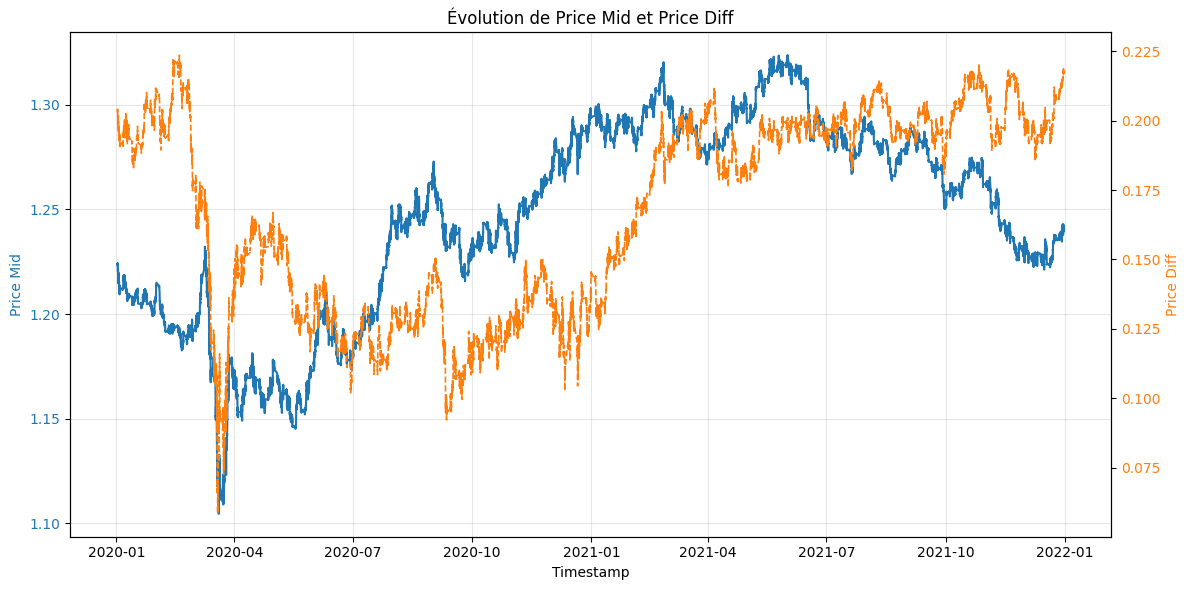

In [11]:
import matplotlib.pyplot as plt

# 1. Configuration de la figure
fig, ax1 = plt.subplots(figsize=(12, 6))

# 2. Première ligne : price_mid (Axe Y à gauche)
color_mid = '#1f77b4' # Bleu
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('Price Mid', color=color_mid)
ax1.plot(df['timestamp'], df['price_mid'], color=color_mid, label='Price Mid', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor=color_mid)
ax1.grid(True, alpha=0.3)

# 3. Deuxième ligne : price_diff (Axe Y à droite)
ax2 = ax1.twinx()  # Partage le même axe X
color_diff = '#ff7f0e' # Orange
ax2.set_ylabel('Price Diff', color=color_diff)
ax2.plot(df['timestamp'], df['price_diff'], color=color_diff, label='Price Diff', linewidth=1.2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color_diff)

# 4. Titre et affichage
plt.title('Évolution de Price Mid et Price Diff')
fig.tight_layout() # Évite le chevauchement des labels
plt.show()


## Rolling mean

In [24]:
df['mid_mean10'] = df['price_mid'].rolling(10).mean()
df['mid_mean40'] = df['price_mid'].rolling(40).mean()
df['diff_mean10'] = df['price_diff'].rolling(10).mean()
df['diff_mean40'] = df['price_diff'].rolling(40).mean()
df.dropna()

,timestamp,x_close,y_close,price_mid,price_diff,mid_mean10,mid_mean40,diff_mean10,diff_mean40
39,2020-01-02 17:30:00,1.313440,1.116990,1.215215,0.196450,1.216891,1.220520,0.197597,0.200675
40,2020-01-02 18:00:00,1.313625,1.116745,1.215185,0.196880,1.216525,1.220310,0.197427,0.200494
41,2020-01-02 18:30:00,1.313985,1.117025,1.215505,0.196960,1.216210,1.220115,0.197318,0.200328
42,2020-01-02 19:00:00,1.313345,1.116820,1.215083,0.196525,1.216070,1.219898,0.197221,0.200159
43,2020-01-02 19:30:00,1.312920,1.116635,1.214778,0.196285,1.215939,1.219681,0.197115,0.199988
...,...,...,...,...,...,...,...,...,...
24793,2021-12-30 21:30:00,1.350150,1.132640,1.241395,0.217510,1.240660,1.240574,0.217774,0.216680
24794,2021-12-30 22:00:00,1.350270,1.132365,1.241318,0.217905,1.240787,1.240548,0.217790,0.216743
24795,2021-12-30 22:30:00,1.349950,1.132405,1.241178,0.217545,1.240898,1.240524,0.217834,0.216799
24796,2021-12-30 23:00:00,1.349835,1.132465,1.241150,0.217370,1.241074,1.240507,0.217832,0.216853


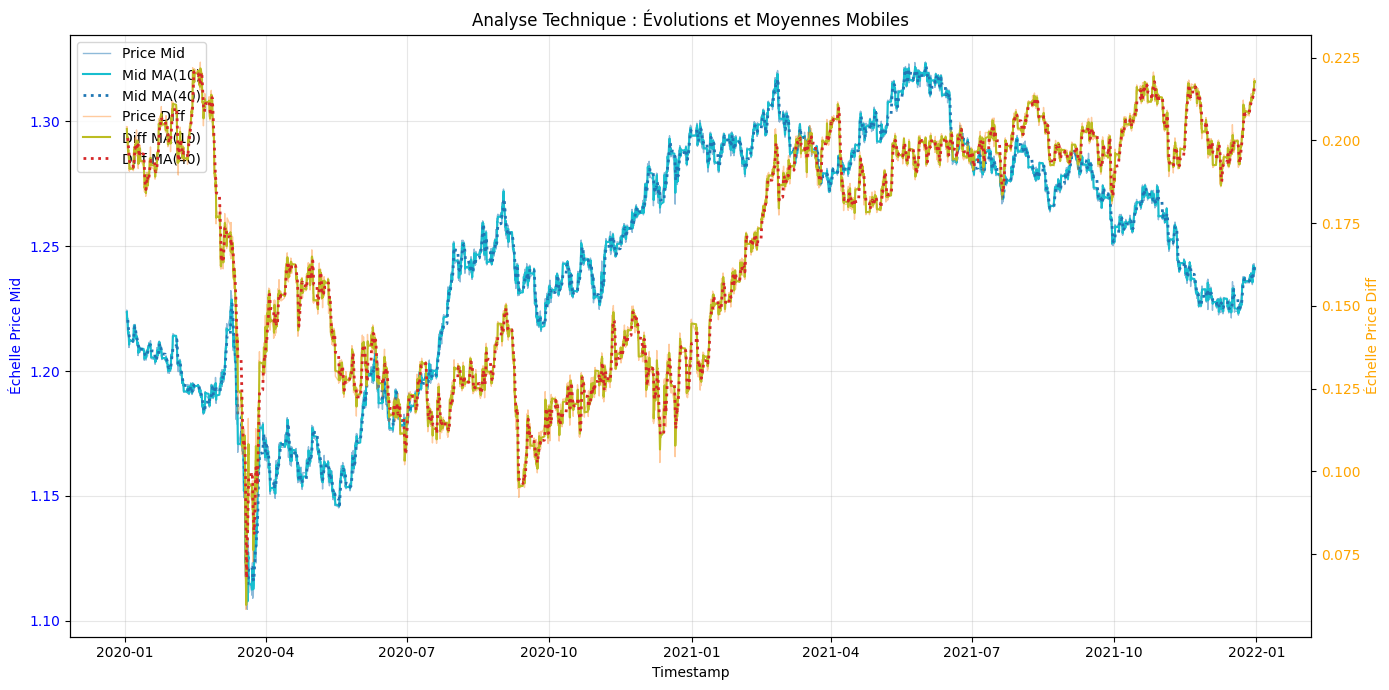

In [25]:
import matplotlib.pyplot as plt

# 2. Configuration de la figure Matplotlib
fig, ax1 = plt.subplots(figsize=(14, 7))

# ----------------------------------------------------
# AXE GAUCHE (Moyenne des prix) : price_mid + Moyennes
# ----------------------------------------------------
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('Échelle Price Mid', color='blue')

ax1.plot(df['timestamp'], df['price_mid'], color='#1f77b4', label='Price Mid', linewidth=1, alpha=0.5)
ax1.plot(df['timestamp'], df['mid_mean10'], color='#17becf', label='Mid MA(10)', linewidth=1.5)
ax1.plot(df['timestamp'], df['mid_mean40'], color='#1f77b4', label='Mid MA(40)', linewidth=2, linestyle=':')

ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True, alpha=0.3)

# ----------------------------------------------------
# AXE DROIT (Écart des prix) : price_diff + Moyennes
# ----------------------------------------------------
ax2 = ax1.twinx() # Partage l'axe X
ax2.set_ylabel("Échelle Price Diff", color='orange')

ax2.plot(df['timestamp'], df['price_diff'], color='#ff7f0e', label='Price Diff', linewidth=1, alpha=0.4)
ax2.plot(df['timestamp'], df['diff_mean10'], color='#bcbd22', label='Diff MA(10)', linewidth=1.5)
ax2.plot(df['timestamp'], df['diff_mean40'], color='#d62728', label='Diff MA(40)', linewidth=2, linestyle=':')

ax2.tick_params(axis='y', labelcolor='orange')

# 3. Fusionner les légendes des deux axes en une seule boîte propre
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Analyse Technique : Évolutions et Moyennes Mobiles')
fig.tight_layout()
plt.show()

## Prepare ticks

In [115]:
from enl.data_feed import *

# start = '2020-01-01'
# end = '2021-12-31'

# # start = '2026-01-01'
# # end = '2026-06-30'

# df_30min = load_pair_time_bars('GBPUSD', 'EURUSD', start, end, '30min', ['close'])
from enl.backtest import *

all_dfs = [df_30min]
windows = [10, 40]

df_unaligned_models = []

for window in windows:
    logger.info('Building models for window=%d', window)
    for df in all_dfs:
        model = bivariate_linear_model(df, window).dropna()
        filters = build_cascade_filters(model, window).dropna()
        df_unaligned_models.append(filters)

# Find the min date of all models and strip everybody
common_start_time = max(df["timestamp"].min() for df in df_unaligned_models)
logger.info('Found common start: %s', common_start_time)

df_models = [df[df["timestamp"] >= common_start_time] for df in df_unaligned_models]

df_30min
df_models

for model in df_models:
    tmp = model[(model['window'] == 10) & (model['time_frame'] == '30min')]
    if len(tmp) > 0:
        df_30min_w10 = tmp
        break
df_30min_w10

for model in df_models:
    tmp = model[(model['window'] == 40) & (model['time_frame'] == '30min')]
    if len(tmp) > 0:
        df_30min_w40 = tmp
        break
df_30min_w40

[INFO] Building models for window=10
[INFO] Building models for window=40
[INFO] Found common start: 2020-01-02 17:30:00


,timestamp,time_frame,half_year_index,x_close,y_close,window,price_mid,price_diff,price_diff_sq,price_diff_sq_diff,efficiency_ratio,ols_slope,ols_intercept,r2,beta_tstat,sigma_alpha,residual_sigma,z_fixed,z_dynamic,variance_minimal,variance_prediction,student_barrier,is_r2_valid,is_ttest_valid,is_anchor_valid,is_slope_valid,raw_residual,is_efficiency_ratio_valid
39,2020-01-02 17:30:00,30min,S1,1.313440,1.116990,40,1.220520,0.200675,0.040270,0.040270,0.000000,0.415204,0.571758,0.882717,16.911635,0.032429,0.000567,-0.199655,-0.187965,8.029958e-09,3.623911e-07,2.024394,True,True,True,True,-0.000113,True
40,2020-01-02 18:00:00,30min,S1,1.313625,1.116745,40,1.220310,0.200494,0.040198,-0.000072,0.996413,0.426274,0.557143,0.894793,17.977580,0.031312,0.000560,-0.647575,-0.614372,7.852922e-09,3.489866e-07,2.024394,True,True,True,True,-0.000363,False
41,2020-01-02 18:30:00,30min,S1,1.313985,1.117025,40,1.220115,0.200328,0.040131,-0.000066,0.993128,0.432990,0.548284,0.902454,18.749891,0.030489,0.000555,-0.361349,-0.345553,7.708707e-09,3.371844e-07,2.024394,True,True,True,True,-0.000201,False
42,2020-01-02 19:00:00,30min,S1,1.313345,1.116820,40,1.219898,0.200159,0.040064,-0.000068,0.989790,0.434944,0.545702,0.905828,19.118539,0.030029,0.000556,-0.204853,-0.195429,7.715816e-09,3.391166e-07,2.024394,True,True,True,True,-0.000114,False
43,2020-01-02 19:30:00,30min,S1,1.312920,1.116635,40,1.219681,0.199988,0.039995,-0.000068,0.986437,0.437163,0.542774,0.909576,19.551079,0.029508,0.000555,-0.178088,-0.169882,7.714044e-09,3.390921e-07,2.024394,True,True,True,True,-0.000099,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24793,2021-12-30 21:30:00,30min,S4,1.350150,1.132640,40,1.240574,0.216680,0.046950,0.000018,1.000000,0.554804,0.383852,0.447696,5.550020,0.134843,0.000931,-0.300754,-0.294544,2.166465e-08,9.035103e-07,2.024394,True,True,True,True,-0.000280,False
24794,2021-12-30 22:00:00,30min,S4,1.350270,1.132365,40,1.240548,0.216743,0.046977,0.000027,1.000000,0.521644,0.428521,0.442856,5.495910,0.128033,0.000886,-0.582543,-0.569614,1.964677e-08,8.219513e-07,2.024394,True,True,True,True,-0.000516,False
24795,2021-12-30 22:30:00,30min,S4,1.349950,1.132405,40,1.240524,0.216799,0.047002,0.000025,1.000000,0.499226,0.458707,0.453989,5.621006,0.119804,0.000831,-0.278705,-0.273682,1.726052e-08,7.159968e-07,2.024394,True,True,True,True,-0.000232,False
24796,2021-12-30 23:00:00,30min,S4,1.349835,1.132465,40,1.240507,0.216853,0.047025,0.000023,1.000000,0.487631,0.474298,0.478914,5.909704,0.111305,0.000774,-0.071142,-0.069955,1.499462e-08,6.203158e-07,2.024394,True,True,True,True,-0.000055,False


## Define Bots

In [116]:
from enl.backtest import BacktestEngine

swing_config = {
    'use_r2': True,
    'use_ttest': False,
    'use_anchor': True,
    'use_slope_limit': False,
    'use_z_dynamic': False,
    'use_elastic_sizing': False,
}

intraday_config = {
    'use_r2': False,
    'use_ttest': False,
    'use_anchor': True,
    'use_slope_limit': True,
    'use_z_dynamic': True,
    'use_elastic_sizing': False,
}

bots = [
    {
        'name': 'swing_s1_spec',
        'params': { **swing_config, 'stop_loss_sigma': 1.5 },
        'model': df_30min_w10,
    },
    {
        'name': 'swing_s1_spec_sniper',
        'params': { **swing_config, 'stop_loss_sigma': 1.5, 'use_z_dynamic': True },
        'model': df_30min_w10,
    },
    {
        'name': 'swing_generalist',
        'params': { **swing_config, 'stop_loss_sigma': 3.5 },
        'model': df_30min_w10,
    },
    {
        'name': 'swing_generalist_sniper',
        'params': { **swing_config, 'stop_loss_sigma': 3.5, 'use_z_dynamic': True  },
        'model': df_30min_w10,
    },
    {
        'name': 'intraday_w40_s4spec',
        'params': { **intraday_config, 'stop_loss_sigma': 1.5 },
        'model': df_30min_w40,
    },
    {
        'name': 'intraday_w40_generalist',
        'params': { **intraday_config, 'stop_loss_sigma': 3.5 },
        'model': df_30min_w40,
    },
]

## Single Backtest

In [117]:
from enl.backtest import *

# # 1. Sélection du bot à tester (exemple avec le swing_generalist)
# bot_to_test = {
#     'name': 'swing_generalist',
#     'params': {
#         'use_r2': True,
#         'use_ttest': False,
#         'use_anchor': True,
#         'use_slope_limit': False,
#         'use_z_dynamic': False,
#         'use_elastic_sizing': False,
#         'stop_loss_sigma': 3.5
#     },
#     'model': df_30min_w10, # Votre DataFrame OLS contenant price_diff et price_diff_sq
# }

bot_to_test = bots[2] # 2 = swing generalist, 5 = intraday generalist

# 2. Initialisation de la stratégie et du moteur
strategy = FixedParameterWithStopStrategy(**bot_to_test['params'], use_efficiency_ratio=True)
engine = BacktestEngine()

# 3. Lancement de la simulation (génère le df avec capital, price_diff, price_diff_sq)
print(f"Lancement du backtest pour : {bot_to_test['name']}")
df_single_equity = engine.run_simulation(bot_to_test['model'], strategy)

# 4. Calcul vectoriel du rendement cumulé (cum_return)
df_single_equity['return_pct'] = (df_single_equity['capital'] - df_single_equity['capital'].shift()) / df_single_equity['capital'].shift()
df_single_equity['return_pct'] = df_single_equity['return_pct'].fillna(0)
df_single_equity['cum_return'] = df_single_equity['return_pct'].cumsum()

# 5. Extraction des métriques globales de performance
performance_report = engine.compute_performance_metrics()
df_single_equity


Lancement du backtest pour : swing_generalist
[INFO] Starting chronological simulation loop...


[INFO] [2020-01-23 15:30:00] Execution: OPEN LONG_SPREAD
[INFO] [2020-01-23 16:30:00] Execution: CLOSE | Gross PnL: 302.13 | Net PnL: 274.34 | Net Balance: 100274.34
[INFO] [2020-01-29 15:00:00] Execution: OPEN SHORT_SPREAD
[INFO] [2020-01-29 17:00:00] Execution: CLOSE | Gross PnL: 98.09 | Net PnL: 87.33 | Net Balance: 100361.68
[INFO] [2020-02-13 08:30:00] Execution: OPEN SHORT_SPREAD
[INFO] [2020-02-13 10:30:00] Execution: CLOSE | Gross PnL: 232.47 | Net PnL: 220.42 | Net Balance: 100582.09
[INFO] [2020-03-16 14:30:00] Execution: OPEN LONG_SPREAD
[INFO] [2020-03-16 16:00:00] Execution: CLOSE | Gross PnL: 574.36 | Net PnL: 559.99 | Net Balance: 101142.08
[INFO] [2020-03-17 07:00:00] Execution: OPEN LONG_SPREAD
[INFO] [2020-03-17 07:30:00] Execution: CLOSE | Gross PnL: 251.61 | Net PnL: 236.07 | Net Balance: 101378.15
[INFO] [2020-04-01 07:30:00] Execution: OPEN LONG_SPREAD
[INFO] [2020-04-01 10:00:00] Execution: CLOSE | Gross PnL: -412.75 | Net PnL: -431.03 | Net Balance: 100947.12
[I

,capital,price_diff_sq,efficiency_ratio,return_pct,cum_return
timestamp,,,,,
2020-01-02 17:30:00,100000.000000,0.039045,1.000000,0.0,0.000000
2020-01-02 18:00:00,100000.000000,0.038977,1.000000,0.0,0.000000
2020-01-02 18:30:00,100000.000000,0.038934,1.000000,0.0,0.000000
2020-01-02 19:00:00,100000.000000,0.038896,1.000000,0.0,0.000000
2020-01-02 19:30:00,100000.000000,0.038854,1.000000,0.0,0.000000
...,...,...,...,...,...
2021-12-30 21:30:00,101036.878686,0.047425,0.384522,0.0,0.010456
2021-12-30 22:00:00,101036.878686,0.047432,0.261512,0.0,0.010456
2021-12-30 22:30:00,101036.878686,0.047451,0.410433,0.0,0.010456


In [118]:
# 3. Calcul de la corrélation instantanée (Performance par bougie vs ER)
corr_instant = df_single_equity['efficiency_ratio'].corr(df_single_equity['return_pct'], method='pearson')

# 4. Calcul de la corrélation globale de structure (Courbe globale vs ER)
corr_global = df_single_equity['efficiency_ratio'].corr(df_single_equity['cum_return'], method='spearman')

print(f"Corrélation Instantanée (Chaque bougie) : {corr_instant:.4f}")
print(f"Corrélation Globale (Effet Miroir)     : {corr_global:.4f}")

# 1. On ne garde QUE les lignes où le bot a réellement subi une perte
df_losses = df_single_equity[df_single_equity['return_pct'] < 0]
df_wins = df_single_equity[df_single_equity['return_pct'] > 0]

# 2. On regarde la valeur moyenne de l'ER pendant ces pertes
er_mean_during_losses = df_losses['efficiency_ratio'].mean()
er_mean_during_wins = df_wins['efficiency_ratio'].mean()

# 3. On compare avec la valeur moyenne générale de l'ER sur tout le backtest
er_mean_global = df_single_equity['efficiency_ratio'].mean()

print(f"Valeur moyenne de l'ER (Générale)       : {er_mean_global:.4f}")
print(f"Valeur moyenne de l'ER pendant les PERTES : {er_mean_during_losses:.4f}")
print(f"Valeur moyenne de l'ER pendant les GAINS : {er_mean_during_wins:.4f}")

performance_report


Corrélation Instantanée (Chaque bougie) : -0.0082
Corrélation Globale (Effet Miroir)     : 0.0369
Valeur moyenne de l'ER (Générale)       : 0.7325
Valeur moyenne de l'ER pendant les PERTES : 0.6661
Valeur moyenne de l'ER pendant les GAINS : 0.5517


{'total_trades': 39,
 'win_trades_gross': 26,
 'loss_trades_gross': 13,
 'avg_win_pct_gross': 0.00204891061480534,
 'avg_loss_pct_gross': -0.0028895103898824905,
 'win_ratio_gross': 0.6666666666666666,
 'reward_ratio_gross': 0.7090857406083473,
 'profit_factor_gross': 1.4130874585202458,
 'recovery_factor_gross': 2.3781555188006998,
 'sharpe_ratio_gross': 0.6812318423224066,
 'sortino_ratio_gross': 0.5495854101766895,
 'calmar_ratio_gross': 1.2377862385774732,
 'max_consecutive_wins_gross': 6,
 'max_consecutive_losses_gross': 5,
 'relative_expected_value_gross': 0.0004027702799093963,
 'cumulative_monetary_profit_gross': 1568.7706201036556,
 'win_trades_net': 26,
 'loss_trades_net': 13,
 'avg_win_pct_net': 0.001918371729593871,
 'avg_loss_pct_net': -0.0030324312791225835,
 'win_ratio_net': 0.6666666666666666,
 'reward_ratio_net': 0.6326183688980219,
 'profit_factor_net': 1.260848194395643,
 'recovery_factor_net': 1.571841502970886,
 'sharpe_ratio_net': 0.4530255002751821,
 'sortino_rat

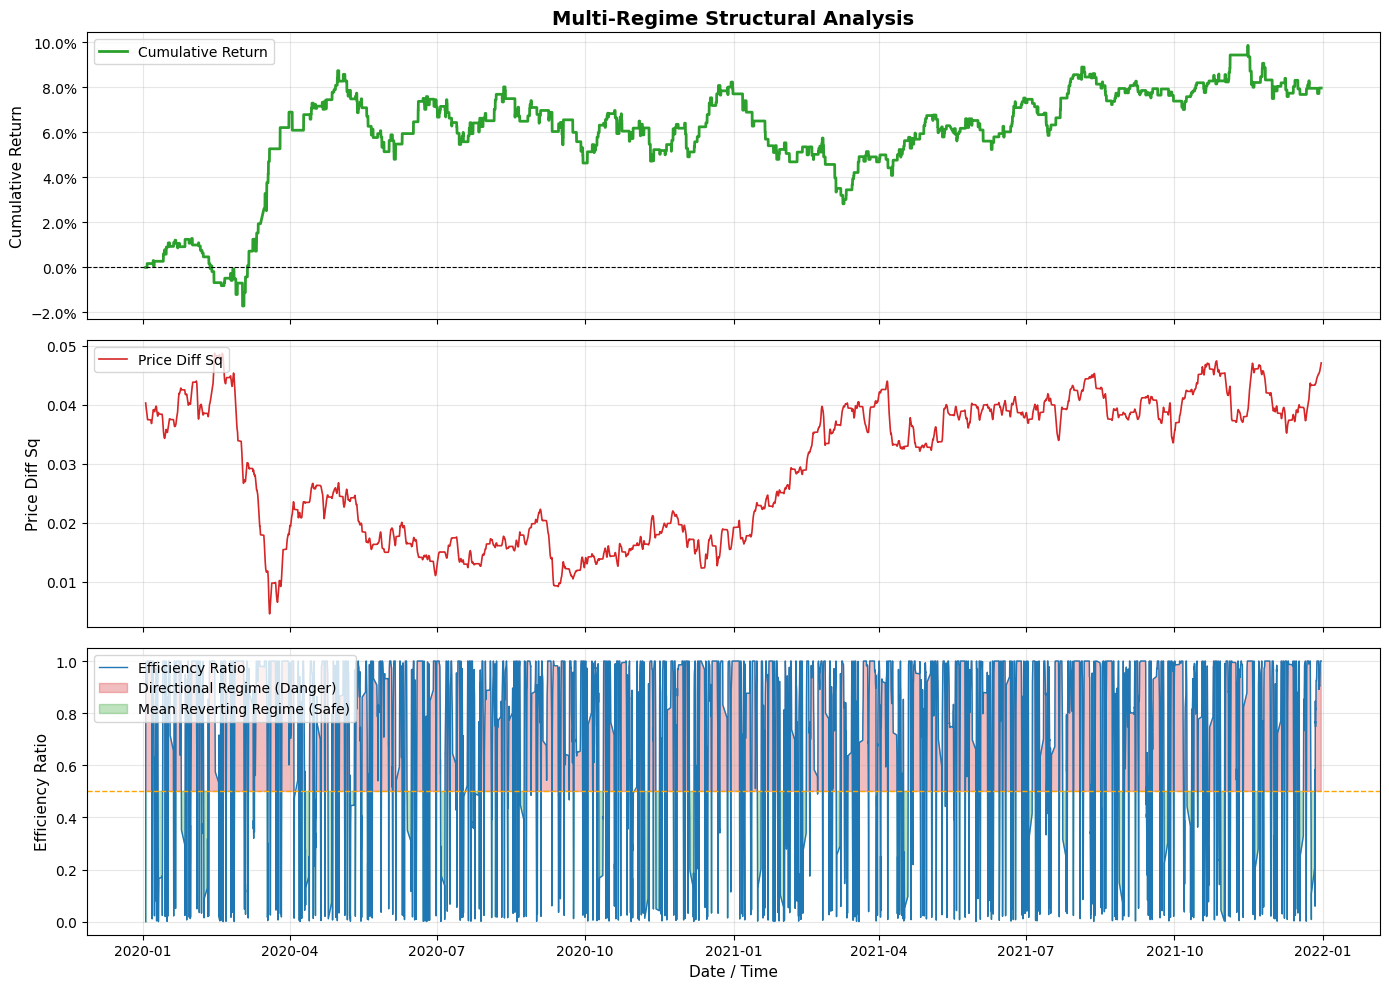

In [97]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df_plot = df_single_equity.dropna(subset=['efficiency_ratio'])

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Stack 1: Cumulative Return
ax1.plot(df_plot.index, df_plot['cum_return'], color='#2ca02c', linewidth=2, label='Cumulative Return')
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax1.set_title(f"Multi-Regime Structural Analysis", fontsize=14, fontweight='bold')
ax1.set_ylabel('Cumulative Return', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Stack 2: Price Diff Sq
ax2.plot(df_plot.index, df_plot['price_diff_sq'], color='#d62728', linewidth=1.2, label='Price Diff Sq')
ax2.set_ylabel('Price Diff Sq', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper left')

# Stack 3: Efficiency Ratio
ax3.plot(df_plot.index, df_plot['efficiency_ratio'], color='#1f77b4', linewidth=1, label='Efficiency Ratio')
ax3.fill_between(df_plot.index, df_plot['efficiency_ratio'], 0.5, where=(df_plot['efficiency_ratio'] > 0.5), color='#d62728', alpha=0.3, label='Directional Regime (Danger)')
ax3.fill_between(df_plot.index, df_plot['efficiency_ratio'], 0.5, where=(df_plot['efficiency_ratio'] <= 0.5), color='#2ca02c', alpha=0.3, label='Mean Reverting Regime (Safe)')
ax3.axhline(0.5, color='orange', linestyle='--', linewidth=1)
ax3.set_xlabel('Date / Time', fontsize=11)
ax3.set_ylabel('Efficiency Ratio', fontsize=11)
ax3.set_ylim(-0.05, 1.05)
ax3.grid(True, alpha=0.3)
ax3.legend(loc='upper left')

plt.tight_layout()
plt.show()
